# 3-Layer CNN for MNIST — implemented entirely with `einops` / `einsum`

Every layer (convolutions, max-pooling, flatten, dense classifier) is built **by hand** using `einops.rearrange` and `einops.einsum` instead of `torch.nn.Conv2d` / `torch.nn.Linear`.

Architecture (3 convolutional layers + 1 dense head):

| Stage | Operation |
|-------|-----------|
| Conv 1 | 1 -> 16 channels, 3x3, ReLU, 2x2 max-pool |
| Conv 2 | 16 -> 32 channels, 3x3, ReLU, 2x2 max-pool |
| Conv 3 | 32 -> 64 channels, 3x3, ReLU, 2x2 max-pool |
| Head   | Flatten -> Dense (64*4*4 -> 10) |

Trained for **5 epochs**; test accuracy and a 4x4 grid of 16 samples (image + ground truth + prediction) are reported below.

## 0. Install & import

In [1]:
# Uncomment if running on a fresh DGX / environment:
# !pip install torch torchvision einops matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from einops import rearrange, einsum
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## 1. Load MNIST

In [2]:
batch_size = 128
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1000, shuffle=False)
print("Train samples:", len(train_ds), "| Test samples:", len(test_ds))

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<01:25, 115kB/s]

  1%|          | 65.5k/9.91M [00:00<01:14, 132kB/s]

  2%|▏         | 197k/9.91M [00:00<00:29, 325kB/s] 

  4%|▍         | 393k/9.91M [00:01<00:19, 498kB/s]

...

 91%|█████████▏| 1.51M/1.65M [00:01<00:00, 1.49MB/s]

100%|██████████| 1.65M/1.65M [00:01<00:00, 960kB/s] 

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 4.91MB/s]

Train samples: 60000 | Test samples: 10000


## 2. Hand-built layers using `einops` / `einsum`

In [3]:
def conv2d_einops(x, weight, bias, stride=1, padding=1):
    """2D convolution implemented with einops.rearrange + einops.einsum.
    x:      [b, c_in, h, w]
    weight: [c_out, c_in, k, k]
    bias:   [c_out]
    """
    if padding:
        x = F.pad(x, (padding, padding, padding, padding))
    kh, kw = weight.shape[2], weight.shape[3]
    # sliding windows via unfold, then reorder with einops
    x_unf = x.unfold(2, kh, stride).unfold(3, kw, stride)
    x_unf = rearrange(x_unf, 'b c_in h w kh kw -> b h w c_in kh kw')
    # core convolution as a single einsum
    out = einsum(x_unf, weight,
                 'b h w c_in kh kw, c_out c_in kh kw -> b h w c_out')
    out = rearrange(out, 'b h w c_out -> b c_out h w')
    return out + bias.reshape(1, -1, 1, 1)


def maxpool2d_einops(x, k=2, padding=0):
    """k x k max-pooling implemented with einops.rearrange + max.

    Zero-pads the bottom/right edges when the spatial size is not
    divisible by k (e.g. 7x7 -> 8x8 -> 4x4) so the reshape stays valid.
    """
    if padding:
        x = F.pad(x, (padding, padding, padding, padding))
    h, w = x.shape[2], x.shape[3]
    ph, pw = h % k, w % k
    if ph or pw:
        x = F.pad(x, (0, pw, 0, ph))
    x = rearrange(x, 'b c (h ph) (w pw) -> b c h w (ph pw)', ph=k, pw=k)
    return x.max(dim=-1).values


def dense_einops(x, weight, bias):
    """Fully-connected layer implemented with einops.einsum.
    x: [b, i]   weight: [o, i]   bias: [o]
    """
    return einsum(x, weight, 'b i, o i -> b o') + bias

## 3. The 3-layer CNN model

In [4]:
class ManualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 convolutional layers
        self.w1 = nn.Parameter(torch.randn(16, 1, 3, 3) * 0.1)
        self.b1 = nn.Parameter(torch.zeros(16))
        self.w2 = nn.Parameter(torch.randn(32, 16, 3, 3) * 0.1)
        self.b2 = nn.Parameter(torch.zeros(32))
        self.w3 = nn.Parameter(torch.randn(64, 32, 3, 3) * 0.1)
        self.b3 = nn.Parameter(torch.zeros(64))
        # dense head: 64 channels * 4 * 4 -> 10 classes
        # (3 max-pools on 28x28 -> 4x4 after the final padded pool)
        self.wf = nn.Parameter(torch.randn(10, 64 * 4 * 4) * 0.1)
        self.bf = nn.Parameter(torch.zeros(10))

    def forward(self, x):
        x = F.relu(conv2d_einops(x, self.w1, self.b1))
        x = maxpool2d_einops(x, 2)
        x = F.relu(conv2d_einops(x, self.w2, self.b2))
        x = maxpool2d_einops(x, 2)
        x = F.relu(conv2d_einops(x, self.w3, self.b3))
        x = maxpool2d_einops(x, 2)
        x = rearrange(x, 'b c h w -> b (c h w)')
        return dense_einops(x, self.wf, self.bf)


model = ManualCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

Total parameters: 33,546


## 4. Train for 5 epochs

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 5
for epoch in range(1, epochs + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    print(f"Epoch {epoch}/{epochs} | loss: {running_loss/total:.4f} | "
          f"train acc: {correct/total:.4f}")

Epoch 1/5 | loss: 0.2547 | train acc: 0.9236


Epoch 2/5 | loss: 0.0644 | train acc: 0.9801


Epoch 3/5 | loss: 0.0428 | train acc: 0.9866


Epoch 4/5 | loss: 0.0334 | train acc: 0.9892


Epoch 5/5 | loss: 0.0271 | train acc: 0.9918


## 5. Test-split accuracy

In [6]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc:.4f} ({correct}/{total})")

Test accuracy: 0.9880 (9880/10000)


## 6. 4x4 grid — 16 samples with ground truth & prediction

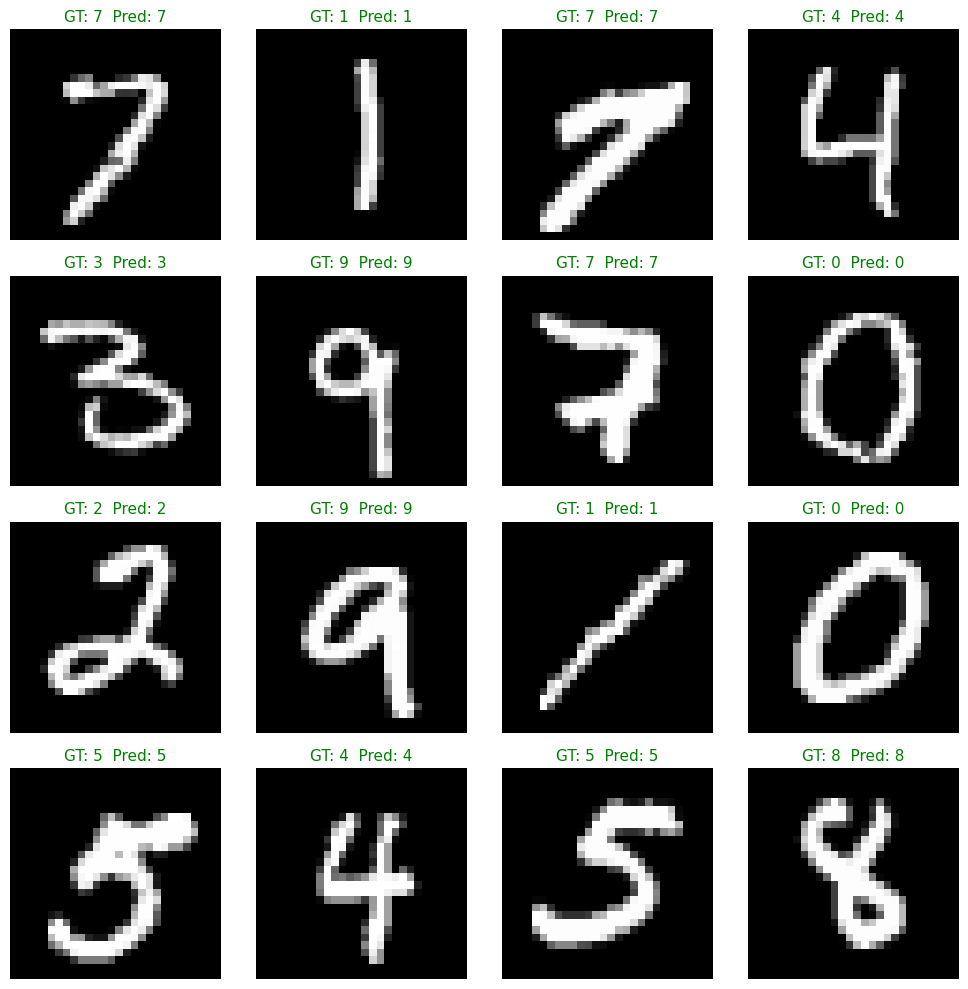

In [7]:
model.eval()
samples = next(iter(DataLoader(test_ds, batch_size=16, shuffle=True)))
images, labels = samples
with torch.no_grad():
    preds = model(images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap="gray")
    gt, pred = labels[i].item(), preds[i].item()
    color = "green" if gt == pred else "red"
    ax.set_title(f"GT: {gt}  Pred: {pred}", color=color, fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.show()